# Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import Data 

In [12]:
# load dataset from csv file
df = pd.read_csv("expense.csv")


# Data Cleaning

In [13]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert participants to list
df['participants'] = df['participants'].str.split(',')

# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Convert amount
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

# Fix name consistency 
df['payer'] = df['payer'].str.strip()


# Numpy Analysis

In [9]:
print("Average Expense:", np.mean(df['amount']))
print("Maximum Expense:", np.max(df['amount']))
print("Minimum Expense:", np.min(df['amount']))
print("Standard Deviation:", np.std(df['amount']))

Average Expense: 485.0
Maximum Expense: 1500
Minimum Expense: 0
Standard Deviation: 426.64387959983674


# Expense Sharing class

In [10]:
class ExpenseSharing:

    def __init__(self, friends):
        self.friends = friends
        self.balances = {friend: 0 for friend in friends}
        self.missed_payments = []   # NEW

    def addExpense(self, payer, amount, participants):

        # Track missed payments
        if amount == 0:
            self.missed_payments.append(payer)
            return

        split_amount = amount / len(participants)

        for participant in participants:
            self.balances[participant] -= split_amount

        self.balances[payer] += amount

    def calculateSettlement(self):

        debtors = []
        creditors = []

        for friend, balance in self.balances.items():
            if balance > 0:
                creditors.append((friend, balance))
            elif balance < 0:
                debtors.append((friend, -balance))

        print("\n----- FINAL SETTLEMENT -----")

        while creditors and debtors:
            debtor, debt_amount = debtors.pop()
            creditor, credit_amount = creditors.pop()

            payment = min(debt_amount, credit_amount)

            print(f"{debtor} should pay {creditor} Rs.{payment:.2f}")

            if debt_amount > payment:
                debtors.append((debtor, debt_amount - payment))

            if credit_amount > payment:
                creditors.append((creditor, credit_amount - payment))

        # Show missed payments
        if self.missed_payments:
            print("\nMissed Payments by:")
            print(", ".join(set(self.missed_payments)))
            print("\nFinal Balances:")
            print(self.balances)

# Run Expense Logic

In [11]:
friends = list(set(df['payer']))

expense_obj = ExpenseSharing(friends)

for _, row in df.iterrows():
    expense_obj.addExpense(
        row['payer'],
        row['amount'],
        row['participants']
    )

expense_obj.calculateSettlement()



----- FINAL SETTLEMENT -----
Bala should pay Arun Rs.777.50
Karthik should pay Arun Rs.140.00
Priya should pay Arun Rs.527.50
Divya should pay Arun Rs.827.50

Missed Payments by:
Divya, Bala, Karthik, Priya

Final Balances:
{'Divya': -827.5, 'Priya': -527.5000000000002, 'Arun': 2272.5, 'Karthik': -140.0, 'Bala': -777.5}


# Data Insights

In [17]:
# Total spending per user
total_spent = df.groupby('payer')['amount'].sum()
print("\nTotal Spending per User:\n", total_spent)

# Category-wise spending
category_spent = df.groupby('category')['amount'].sum()
print("\nCategory-wise Spending:\n", category_spent)

# Date-wise spending
date_spent = df.groupby('date')['amount'].sum()
print("\nDate-wise Spending:\n", date_spent)

# NEW: Top spender
print("\nTop Spender:", total_spent.idxmax())
print("Highest spending category:", category_spent.idxmax())


Total Spending per User:
 payer
Arun       4600
Bala       1100
Divya      1000
Karthik    1950
Priya      1050
Name: amount, dtype: int64

Category-wise Spending:
 category
food        3450
rent        1500
shopping    2850
travel      1900
Name: amount, dtype: int64

Date-wise Spending:
 date
2026-01-04    1200
2026-02-04     300
2026-03-04       0
2026-04-04     800
2026-05-04     200
2026-06-04    1500
2026-07-04       0
2026-08-04     700
2026-09-04     400
2026-10-04       0
2026-11-04     900
2026-12-04     600
Name: amount, dtype: int64

Top Spender: Arun
Highest spending category: food


# Visualisation 

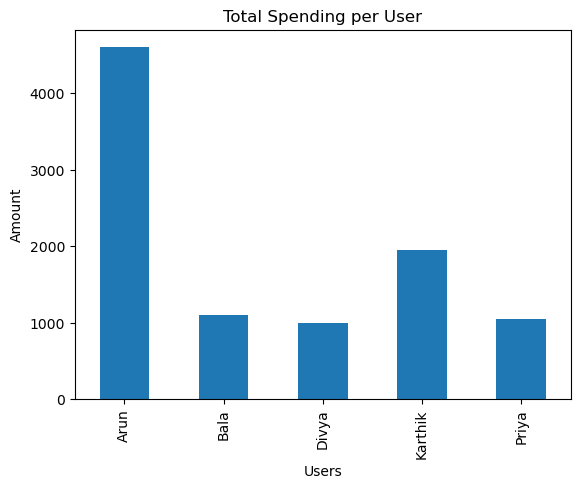

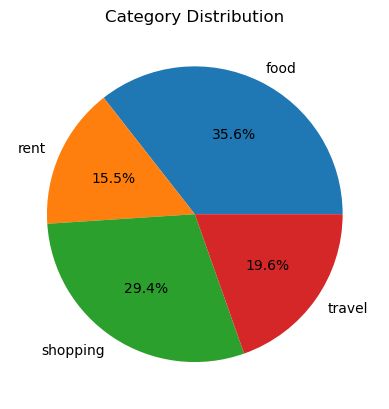

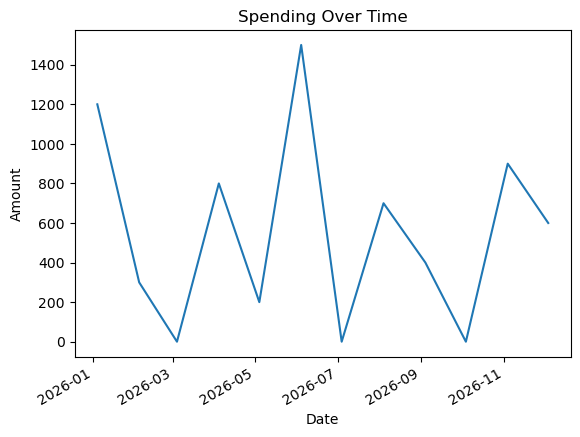

In [15]:
# Bar Chart
total_spent.plot(kind='bar')
plt.title("Total Spending per User")
plt.xlabel("Users")
plt.ylabel("Amount")
plt.show()
# Pie Chart
category_spent.plot(kind='pie', autopct='%1.1f%%')
plt.title("Category Distribution")
plt.ylabel("")
plt.show()
# Line Chart
date_spent.plot(kind='line')
plt.title("Spending Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.show()